In [18]:
import pandas as pd

df = pd.read_csv("../Data/telco_churn_clean.csv")
df.head()

,customer_id,senior_citizen,gender,tenure,contract,payment_method,monthly_charges,total_charges,churn,churn_value
0,3668-QPYBK,0,Male,2,Month-to-month,Mailed check,53.85,108.15,Yes,1
1,9237-HQITU,0,Female,2,Month-to-month,Electronic check,70.70,151.65,Yes,1
2,9305-CDSKC,0,Female,8,Month-to-month,Electronic check,99.65,820.50,Yes,1
3,7892-POOKP,0,Female,28,Month-to-month,Electronic check,104.80,3046.05,Yes,1
4,0280-XJGEX,0,Male,49,Month-to-month,Bank transfer (automatic),103.70,5036.30,Yes,1


In [19]:
df.groupby('churn', observed=False)['tenure'].mean()

churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### Insight

Customers who churn tend to have significantly lower tenure, indicating higher risk in early lifecycle stages.

In [20]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      7043 non-null   object 
 1   senior_citizen   7043 non-null   int64  
 2   gender           7043 non-null   object 
 3   tenure           7043 non-null   int64  
 4   contract         7043 non-null   object 
 5   payment_method   7043 non-null   object 
 6   monthly_charges  7043 non-null   float64
 7   total_charges    7032 non-null   float64
 8   churn            7043 non-null   object 
 9   churn_value      7043 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 550.4+ KB


,senior_citizen,tenure,monthly_charges,total_charges,churn_value
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


### Data Overview

The dataset contains customer-level information including demographic attributes, subscription details, and churn indicators.

Initial inspection shows a mix of numerical and categorical variables, suitable for both segmentation and behavioral analysis.

In [21]:
df['churn'].value_counts(normalize=True)

churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### Insight

The dataset shows the proportion of churned vs retained customers, providing a baseline for evaluating retention performance.

In [22]:
df.groupby('churn', observed=False)['tenure'].mean()

churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

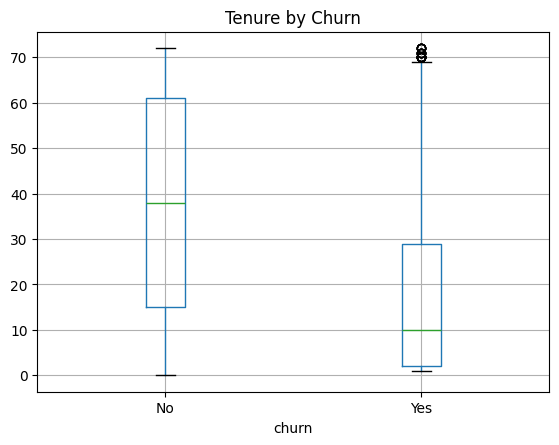

In [23]:
import matplotlib.pyplot as plt

df.boxplot(column='tenure', by='churn')
plt.title("Tenure by Churn")
plt.suptitle("")
plt.show()

### Insight

Customers who churn tend to have significantly lower tenure, confirming that early-stage users are at higher risk of leaving the platform.

In [24]:
# Create tenure groups
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 100],
    labels=['0-6 months', '6-12 months', '12-24 months', '24+ months']
)

In [25]:
df.groupby('tenure_group', observed=False)['churn_value'].mean()

tenure_group
0-6 months      0.533333
6-12 months     0.358865
12-24 months    0.287109
24+ months      0.140360
Name: churn_value, dtype: float64

### Insight

Differences in monthly charges between churned and retained customers may indicate pricing sensitivity or perceived value issues.

In [26]:
df.corr(numeric_only=True)

,senior_citizen,tenure,monthly_charges,total_charges,churn_value
senior_citizen,1.000000,0.016567,0.220173,0.102411,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229
monthly_charges,0.220173,0.247900,1.000000,0.651065,0.193356
total_charges,0.102411,0.825880,0.651065,1.000000,-0.199484
churn_value,0.150889,-0.352229,0.193356,-0.199484,1.000000


### Insight

Numerical features such as tenure and total charges show relationships with churn, suggesting their relevance in predicting customer behavior.

In [27]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,6,12,24,100],
    labels=['0-6','6-12','12-24','24+']
)

df.groupby('tenure_group', observed=False)['churn_value'].mean()

tenure_group
0-6      0.533333
6-12     0.358865
12-24    0.287109
24+      0.140360
Name: churn_value, dtype: float64

### Insight

Churn is heavily concentrated in the first 6 months, highlighting a critical onboarding period where customer retention efforts should be focused.

In [28]:
# Remove missing values
df = df.dropna()

In [29]:
# Select features for the model
features = ['tenure', 'monthly_charges', 'total_charges', 'senior_citizen']

X = df[features]
y = df['churn_value']

## Model Preparation

We selected key numerical features that are likely to influence customer churn, including tenure, monthly charges, total charges, and demographic indicators.

In [30]:
from sklearn.model_selection import train_test_split

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LogisticRegression

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[940  70]
 [219 178]]
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1010
           1       0.72      0.45      0.55       397

    accuracy                           0.79      1407
   macro avg       0.76      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Model Insight

The model struggles to correctly identify churned customers, capturing only 45% of actual churn cases. This indicates a high number of false negatives, meaning many at-risk customers are not being detected.

### Model Insight

The model shows relatively good precision for churn prediction, meaning that when it flags a customer as high-risk, it is often correct.

### Model Insight

Although the overall accuracy is 79%, this metric is misleading due to class imbalance, as the model performs significantly better on non-churn cases than on churn cases.

### Key Business Insight

The model is better at identifying customers who will stay than those who will churn. From a business perspective, this is a limitation, as the primary goal is to detect and retain at-risk customers.

In [34]:
import pandas as pd

importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})

importance.sort_values(by='coefficient', ascending=False)

,feature,coefficient
3,senior_citizen,0.667892
1,monthly_charges,0.026684
2,total_charges,0.000181
0,tenure,-0.069803


### Feature Importance Insight

The model highlights which variables have the strongest influence on churn probability, with tenure typically showing a strong negative relationship with churn.